In [5]:
import numpy as np
import matplotlib.pyplot as plt

Singular Value Decomposition (SVD)

SVD of matrix A is:

A=UDV˄T

Where:

U is an orthogonal m×m matrix; its columns are the left-singular vectors of A.

V is an orthogonal n×n matrix; its columns are the right-singular vectors of A.

D is a diagonal m×n matrix; elements along its diagonal are the singular values of A.

Left singular values and vectors are analogous to eigen values and vectors

As eigendecomposition works only in symmetric matrices SVD works on any matrix

In [6]:
A = np.array([[3,4],[7,9],[1,4]])
A

array([[3, 4],
       [7, 9],
       [1, 4]])

In [7]:
U, d, VT = np.linalg.svd(A)

In [8]:
U

array([[-0.38396343, -0.07179308, -0.92055301],
       [-0.8750869 , -0.28980713,  0.38760127],
       [-0.29460991,  0.95438859,  0.04845016]])

In [9]:
VT

array([[-0.58163327, -0.81345113],
       [-0.81345113,  0.58163327]])

In [10]:
d

array([13.01869908,  1.585394  ])

D  must have the same dimensions as  A  for  UDVT  matrix multiplication to be possible

In [11]:
D =np.diag(d)
D

array([[13.01869908,  0.        ],
       [ 0.        ,  1.585394  ]])

In [12]:

D = np.concatenate((D, [[0,0]]), axis=0)
D

array([[13.01869908,  0.        ],
       [ 0.        ,  1.585394  ],
       [ 0.        ,  0.        ]])

In [13]:
np.dot(U, np.dot(D, VT))

array([[3., 4.],
       [7., 9.],
       [1., 4.]])

SVD and eigendecomposition are closely related to each other:

Left-singular vectors of  A  = eigenvectors of  AA˄T .

Right-singular vectors of  A  = eigenvectors of  A˄TA .

Non-zero singular values of  A  = square roots of eigenvalues of  AA˄T  = square roots of eigenvalues of  A˄TA

SVDs are used in image compression as singular values are arranged in descending order in D, thus the first left singular value and the first right singular value of V have the most prominent feature of the image

In [14]:
Z = np.array([[4,0],[0,3]])
Z[:1]

array([[4, 0]])

Process of image compression with SVD:

An image is a dataset of pixels, for simple compression, we convert the image into grayscale to reduce complexity.

We then convert all the pixels into a long list of scalars, after that we reconstruct a numpy matrix from the list of pixels to enable mathematical operations.

From the new matrix, we solve for SVD, giving us U, D(we have to diag first) and V(already transposed)

In [15]:
from PIL import Image
# Load the image
img = Image.open(r"C:\Users\USER\Downloads\kwa club 2.png")

# Display the image
img.show()

# Optional: Convert to numpy array
#import numpy as np
#img_array = np.array(img)
#print(img_array)


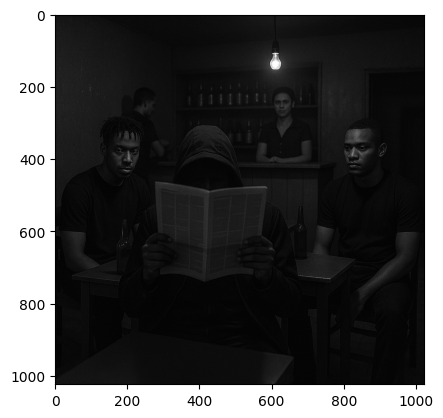

In [16]:
#We convert the image to grey scale
imggray = img.convert('LA')
_ = plt.imshow(imggray)

C:\Users\USER\AppData\Local\Temp\ipykernel_38164\1810659223.py:2: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  imgmat = np.array(list(imggray.getdata(band=0)), float)


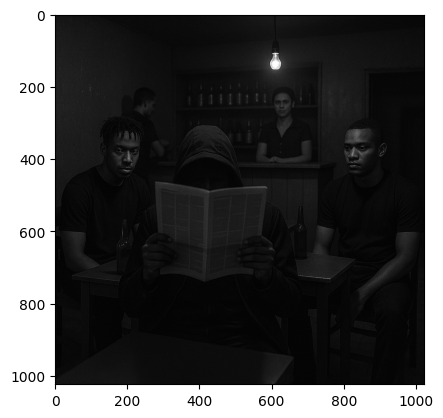

In [17]:
#We take the list of pixel and reconstruct them into a numpy matrix
imgmat = np.array(list(imggray.getdata(band=0)), float)
imgmat.shape = (imggray.size[1], imggray.size[0])
imgmat = np.matrix(imgmat)
_ = plt.imshow(imgmat, cmap='gray')

In [18]:
#Solve for SVD
U, sigma, V = np.linalg.svd(imgmat)

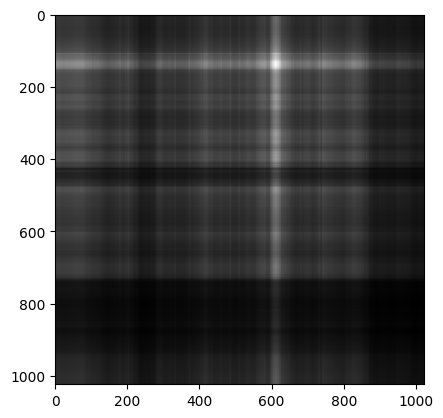

In [19]:
#We then reconstruct the image using the prominent singular values and vectors, be sure it won't be clear
reconstimg = np.matrix(U[:, :1]) * np.diag(sigma[:1]) * np.matrix(V[:1, :])
_ = plt.imshow(reconstimg, cmap='gray')

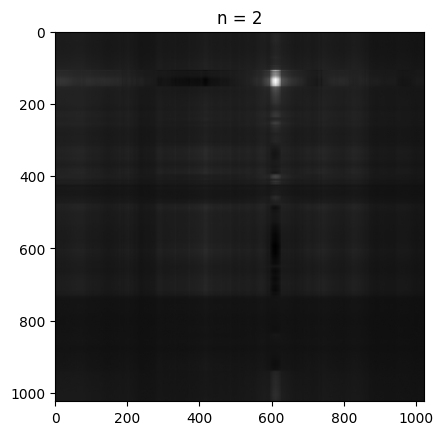

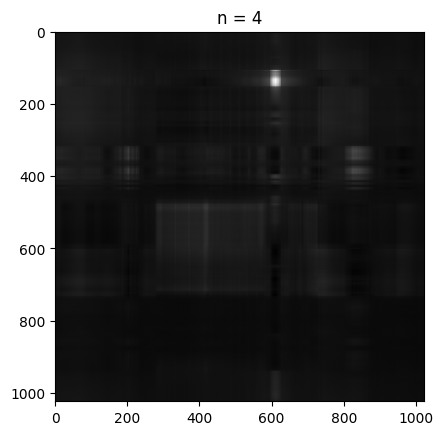

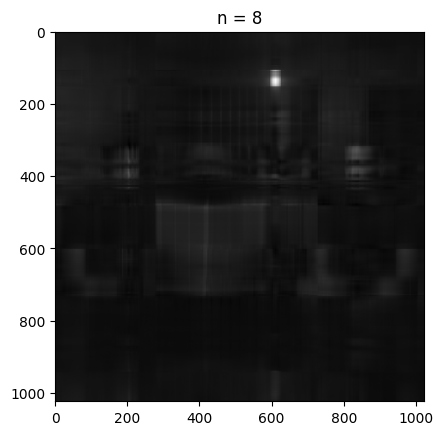

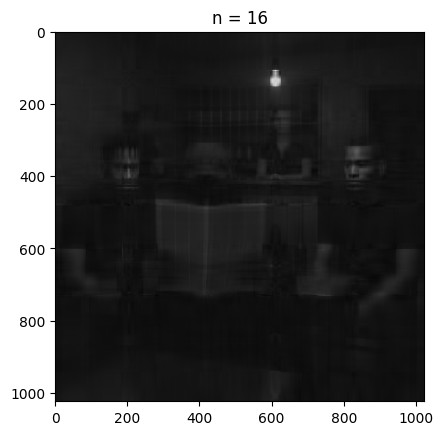

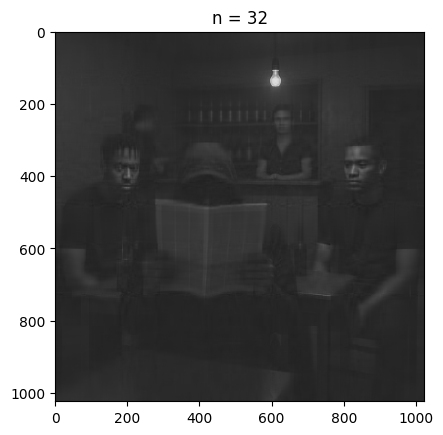

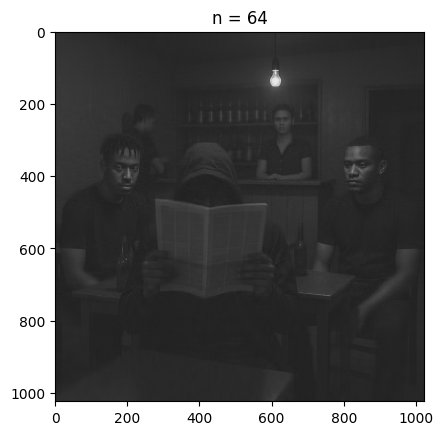

In [20]:
#We then add more singular values and vectors to increase clarity
#Here we use 2 upto 64
for i in [2, 4, 8, 16, 32, 64]:
    reconstimg = np.matrix(U[:, :i]) * np.diag(sigma[:i]) * np.matrix(V[:i, :])
    plt.imshow(reconstimg, cmap='gray')
    title = "n = %s" % i
    plt.title(title)
    plt.show()

In [21]:
imgmat.shape

(1024, 1024)

In [22]:
#We calculate the image size b4 svd decomposition
full_representation = 1024*1024
full_representation

1048576

In [23]:
#We calculate the size after svd decomposition
svd64_rep = 64*1024 + 64 + 64*1024
svd64_rep

131136

In [24]:
#Calculate the percentage image reduction
((full_representation-svd64_rep)/full_representation)*100

87.493896484375